<a href="https://colab.research.google.com/github/KuldeepIsharwal/Machine-Learning-Basics/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Gradient Descent - An iterative optimisation algorithm that finds the minimum of a function by repeatedly taking steps in the direction of steepest descent — the negative of the gradient — until it converges to a minimum.

how to find : - take a random w and b then,

The update rule:


w_new = w_old - η × gradient


Where:

w — the weight (parameter) being updated


η (eta) — the learning rate — how big a step to take


gradient — the slope of the loss function at the current point — tells you the direction of steepest increase

In [2]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

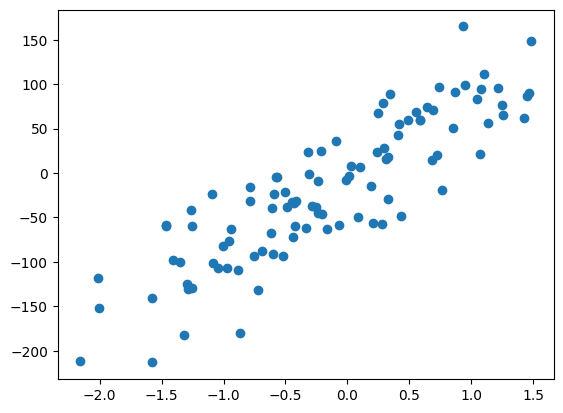

In [3]:
x,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=40)
plt.scatter(x,y)

In [4]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [5]:
lr.fit(x,y)

LinearRegression()

In [6]:
print(lr.intercept_)

-6.111984052130493


In [7]:
lr.coef_

array([78.43240708])

In [8]:
m = lr.intercept_


In [9]:
np.mean(cross_val_score(lr,x,y,scoring='r2',cv=10))

np.float64(0.6565189531519031)

In [10]:
class GDregressor:

    def __init__(self,learning_rate=0.01,epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = -120
        self.b = -120

    def fit(self,x,y):
        #calc b using gd
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - (self.m * x.ravel() + self.b))
            loss_slope_m = -2 * np.sum((y - (self.m * x.ravel() + self.b)) * x.ravel())
            self.b = self.b - self.learning_rate * loss_slope_b
            self.m = self.m - self.learning_rate * loss_slope_m

        print(self.b,self.m)


In [11]:
gd = GDregressor(learning_rate=0.001,epochs=100)

In [12]:
gd.fit(x,y)

-6.11200777393064 78.43236324169547


#Types of gradient Descent :

1.   Batch GD
2.   Stochastic GC
3.   Mini - Batch GD



#1. Batch Gradient Descent

Uses the ENTIRE training dataset to compute the gradient at every step.

Batch GD for n-dim data

In [17]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [14]:
x,y = load_diabetes(return_X_y=True)

In [15]:
x.shape

(442, 10)

In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [20]:
LR = LinearRegression()
LR.fit(x_train,y_train)

LinearRegression()

In [31]:
LR_coef = LR.coef_
LR_intercept = LR.intercept_
print(LR_coef,LR_intercept)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238] 151.88331005254167


In [21]:
y_pred = LR.predict(x_test)
r2_score(y_test,y_pred)

0.4399338661568968

In [28]:
class GDbatch:

    def __init__(self,learning_rate=0.01,epochs=100):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.coef = None
        self.intercept = None

    def fit(self,x,y):
        #init your coef
        self.intercept = 0
        self.coef = np.ones(x.shape[1]) # Changed x_train to x for generality
        for i in range(self.epochs):
            y_hat = np.dot(x,self.coef) + self.intercept
            loss_slope_b = -2 * np.mean(y - y_hat)
            loss_slope_m = -2 * np.dot((y - y_hat),x)/x.shape[0] # Changed x_train to x and y_train to y for generality
            self.intercept = self.intercept - self.learning_rate * loss_slope_b
            self.coef = self.coef - self.learning_rate * loss_slope_m # Corrected: updating self.coef

        print(self.intercept,self.coef) # Corrected: printing self.intercept and self.coef
    def predict(self,x):
        return np.dot(x,self.coef) + self.intercept

In [43]:
gdr = GDbatch(learning_rate=0.7,epochs=100000)

In [44]:
gdr.fit(x_train,y_train)

151.883888917981 [  -9.05164435 -205.02619473  517.74335747  340.41129636 -843.68021648
  520.04501707  130.81176107  120.14035284  841.7308326    52.51861532]
